In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

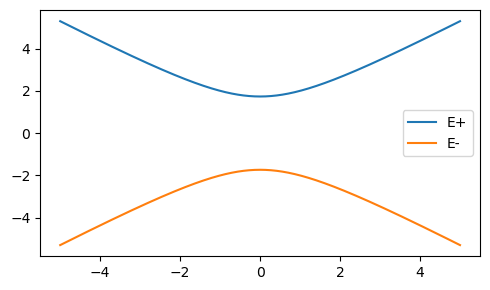

In [3]:
const=2
m=1
c=1
p = np.linspace(-5,5, 1000) 
E1=(-m**2*c**4+const**2+p**2*c**2)**0.5
E2=-1*(-m**2*c**4+const**2+p**2*c**2)**0.5
# 绘制图形
plt.figure(figsize=(5, 3))
plt.plot(p, E1, label='E+')  
plt.plot(p, E2, label='E-')  
plt.legend()
plt.tight_layout()
plt.show()

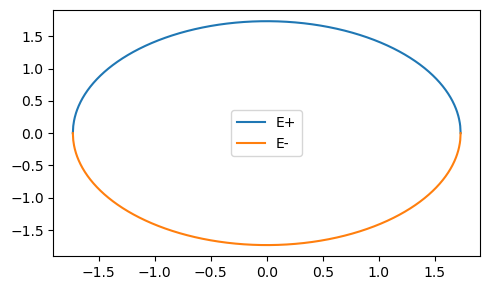

In [4]:
const=1
m=2
c=1
p = np.linspace(-1*((m**2*c**4-const**2)/c**2)**0.5,((m**2*c**4-const**2)/c**2)**0.5, 1000) 
E1=(m**2*c**4-const**2-p**2*c**2)**0.5
E2=-1*(m**2*c**4-const**2-p**2*c**2)**0.5
# 绘制图形
plt.figure(figsize=(5, 3))
plt.plot(p, E1, label='E+')  
plt.plot(p, E2, label='E-')  
plt.legend()
plt.tight_layout()
plt.show()

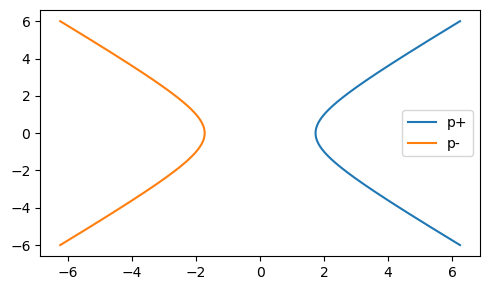

In [5]:
const=1
m=2
c=1
E = np.linspace(-6,6, 1000) 
p1= (E**2+m**2*c**4-const**2)**0.5
p2= -(E**2+m**2*c**4-const**2)**0.5
# 绘制图形
plt.figure(figsize=(5, 3))
plt.plot(p1, E, label='p+')  
plt.plot(p2, E, label='p-')  
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
def suan(const,m,c,x0,x1,p):
    E=(p**2*c**2+const**2-m**2*c**4)**0.5
    a1=(1j*m*c**2+E)/(p*c-1j*const)
    a2=(1j*m*c**2-E)/(p*c-1j*const)
    a3=(1j*m*c**2+E)/(-p*c-1j*const)
    a4=(1j*m*c**2-E)/(-p*c-1j*const)
    A=((a3-a1)*(a4-a1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))
    B=((a1-a2)*(a3-a1)*np.exp(2j*p*x1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))
    T=A+B*np.exp(-2j*p*x1)
    R=(A-1)*np.exp(2j*p*x0)+B
    return T,R

C:\Users\taoji\AppData\Local\Temp\ipykernel_16536\1363402834.py:2: RuntimeWarning: invalid value encountered in scalar power
  E=(p**2*c**2+const**2-m**2*c**4)**0.5
C:\Users\taoji\AppData\Local\Temp\ipykernel_16536\1363402834.py:7: RuntimeWarning: invalid value encountered in scalar divide
  A=((a3-a1)*(a4-a1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))
C:\Users\taoji\AppData\Local\Temp\ipykernel_16536\1363402834.py:8: RuntimeWarning: invalid value encountered in scalar divide
  B=((a1-a2)*(a3-a1)*np.exp(2j*p*x1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))


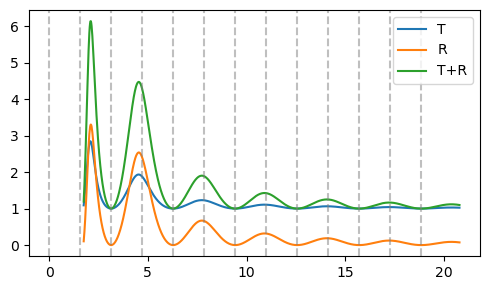

In [7]:
const=1
m=2
c=1
x0=0
x1=1
n=6
p_set = np.linspace(np.sqrt((m**2*c**4-const**2)/c**2), 2*n*np.sqrt((m**2*c**4-const**2)/c**2), 1000)
T_squared = []
R_squared = []
TR_squared = []
for p in p_set:
    T, R = suan(const, m, c, x0, x1, p)
    T_squared.append(np.abs(T)**2)
    R_squared.append(np.abs(R)**2)
    TR_squared.append(np.abs(R)**2+np.abs(T)**2)

plt.figure(figsize=(5, 3))
plt.plot(p_set, T_squared, label='T')  
plt.plot(p_set, R_squared, label='R')  
plt.plot(p_set, TR_squared , label='T+R')
p_gongzhen1=np.linspace(0,n*np.pi/(x1-x0),2*n+1)
for p in p_gongzhen1:
    plt.axvline(x=p, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def suan(const,m,c,x0,x1,p):
    E=(p**2*c**2+const**2-m**2*c**4)**0.5
    a1=(1j*m*c**2+E)/(p*c-1j*const)
    a2=(1j*m*c**2-E)/(p*c-1j*const)
    a3=(1j*m*c**2+E)/(-p*c-1j*const)
    a4=(1j*m*c**2-E)/(-p*c-1j*const)
    A=((a3-a1)*(a4-a1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))
    B=((a1-a2)*(a3-a1)*np.exp(2j*p*x1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))
    T=A+B*np.exp(-2j*p*x1)
    R=(A-1)*np.exp(2j*p*x0)+B
    j1=2*np.real(a1)
    jT=2*np.real(a1)*np.abs(T)**2
    jR=2*np.real(a3)*np.abs(R)**2
    return c*jT,c*jR


C:\Users\taoji\AppData\Local\Temp\ipykernel_16536\1609638005.py:2: RuntimeWarning: invalid value encountered in scalar power
  E=(p**2*c**2+const**2-m**2*c**4)**0.5
C:\Users\taoji\AppData\Local\Temp\ipykernel_16536\1609638005.py:7: RuntimeWarning: invalid value encountered in scalar divide
  A=((a3-a1)*(a4-a1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))
C:\Users\taoji\AppData\Local\Temp\ipykernel_16536\1609638005.py:8: RuntimeWarning: invalid value encountered in scalar divide
  B=((a1-a2)*(a3-a1)*np.exp(2j*p*x1))/((a4-a1)*(a3-a2)+np.exp(2j*p*(x1-x0))*(a1-a2)*(a3-a4))


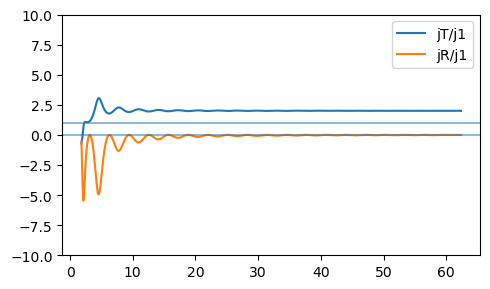

In [15]:
const=1
m=2
c=1
x0=0
x1=1
n=6
p_set = np.linspace(np.sqrt((m**2*c**4-const**2)/c**2), 6*n*np.sqrt((m**2*c**4-const**2)/c**2), 1000)
T_squared = []
R_squared = []
TR_squared = []
for p in p_set:
    T, R = suan(const, m, c, x0, x1, p)
    T_squared.append(T)
    R_squared.append(R)
    TR_squared.append(T+R)

plt.figure(figsize=(5, 3))
plt.plot(p_set, T_squared, label='jT/j1')  
plt.plot(p_set, R_squared, label='jR/j1')  
#plt.plot(p_set, TR_squared , label='jT/j1+jR/j1')
#p_gongzhen1=np.linspace(0,n*np.pi/(x1-x0),2*n+1)
#for p in p_gongzhen1:
#    plt.axvline(x=p, color='gray', linestyle='--', alpha=0.5)
plt.axhline(y=1,  linestyle='-', alpha=0.5)
plt.axhline(y=0,  linestyle='-', alpha=0.5)
plt.ylim(-10,10)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
def suan823(a1,a2,a3,a4,k1,k2,k3,k4,x0,x1):
    kuaini=np.exp(1j*x0*(k1-k3))*(a1-a2)/(a2-a3)
    kuaier=(np.exp(-1j*(k3+k4)*x0)*(a4-a2)/(a2-a3))-np.exp(-1j*(k3+k4)*x1)*((a1-a4)/(a3-a1))
    B=kuaini/kuaier
    A=B*np.exp(-1j*(k4+k3)*x1)*(a1-a4)/(a3-a1)
    T=A*a3*np.exp(1j*(k3-k1)*x1)+B*a4*np.exp(-1j*(k4+k1)*x1)
    R
    return 1